# First-order TDS at a few example zone axes

Minimal, self-contained example that computes the **first-order (one-phonon) thermal diffuse scattering (TDS)** intensity of FCC nickel for a handful of common zone axes ([001], [011], [111], [112]), starting from a phonopy phonon calculation.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import phonopy
from scipy import constants
from scipy.spatial import cKDTree

hbar = constants.hbar   # J s
kb = constants.k        # J / K

## Material parameters (Ni)

Electron scattering-factor coefficients and Debye-Waller-model fit parameters for Ni,
taken from `species.pkl` (the same lookup table `TDS_primative.ipynb` loads via
`Species[atom]`). `Temp` sets the temperature used everywhere below, including the
temperature-dependent Debye-Waller factor computed in the next section — change it
and re-run to get the TDS pattern at a different temperature.

In [2]:
# Ni, from species.pkl
A = [2.2104, 2.1342, 1.6891, 0.5238]        # electron scattering factor coefficients (4-Gaussian fit)
B_coef = [58.7267, 13.553, 2.6094, 0.3388]
M = 58.69                                    # atomic mass, g/mol
Tm = 430                                     # Debye-Waller model reference temperature, K
vm = 8.97                                    # characteristic (Debye) frequency, THz
alpha = 2.639                                # Debye-Waller model fit parameters
fm1 = 1.642
fm2 = 3.364
f2 = 0.491

M_kg = M * 1e-3 / constants.N_A              # kg/atom

Temp = 293                                    # K -- change this and re-run for a different temperature

## Phonon calculation

Load the harmonic force constants (built from a 3x3x3 supercell of the 4-atom
conventional FCC cell) with phonopy. `primitive_matrix='auto'` lets phonopy/spglib
find the 1-atom rhombohedral primitive cell.

In [3]:
phonon = phonopy.load(
    unitcell_filename="POSCAR",
    primitive_matrix="auto",
    supercell_matrix=np.eye(3) * 3,
    force_sets_filename="FORCE_SETS",
)
lattice_constant = np.linalg.norm(phonon.unitcell.cell[0])
print(f"conventional lattice constant a = {lattice_constant:.4f} angstrom")
print(f"primitive cell atoms: {len(phonon.primitive.positions)}")

/opt/homebrew/Caskroom/miniconda/base/envs/phonopy/lib/python3.12/site-packages/phonopy/cui/load.py:277: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000,  0.50000,  0.50000]
  [ 0.50000,  0.00000,  0.50000]
  [ 0.50000,  0.50000,  0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon = Phonopy(


conventional lattice constant a = 3.5180 angstrom
primitive cell atoms: 1


## Phonon dispersion curve

Sanity check on the loaded force constants before using them for TDS: the standard
FCC high-symmetry path $\Gamma - X - W - X' - K - \Gamma - L$, in the primitive
cell's fractional coordinates (the same convention `primitive_matrix="auto"` resolved
to above), same as used elsewhere in this project.

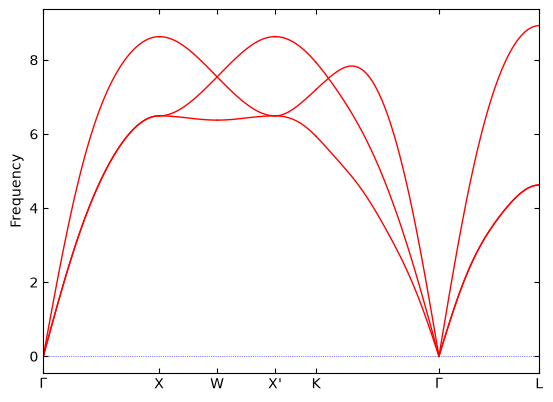

In [4]:
from phonopy.phonon.band_structure import get_band_qpoints_and_path_connections

path = [[[0, 0, 0], [0.5, 0, 0.5], [0.5, 0.25, 0.75], [0.5, 0.5, 1],
         [0.375, 0.375, 0.75], [0, 0, 0], [0.5, 0.5, 0.5]]]
labels = ["$\\Gamma$", "X", "W", "X'", "K", "$\\Gamma$", "L"]

qpoints, connections = get_band_qpoints_and_path_connections(path, npoints=51)
phonon.run_band_structure(qpoints, path_connections=connections, labels=labels)
phonon.plot_band_structure().show()

## Conventional <-> primitive q-point conversion

It's convenient to specify zone axes and scattering vectors as Miller indices of the
**conventional** cubic cell, but phonopy expects q-points as fractional coordinates of
the **primitive** reciprocal cell. The two are related by a fixed linear transform
$T$, derived directly from phonopy's own conventional/primitive lattices (no
hand-typed transformation matrix needed):

In [5]:
B_conv = 2 * np.pi * np.linalg.inv(phonon.unitcell.cell).T   # conventional reciprocal basis
B_prim = 2 * np.pi * np.linalg.inv(phonon.primitive.cell).T  # primitive reciprocal basis
T_conv2prim = B_conv @ np.linalg.inv(B_prim)

def hkl_conv_to_q_prim(hkl_conv):
    # Convert conventional-cell hkl (Cartesian-aligned) to primitive-cell fractional q.
    return np.asarray(hkl_conv) @ T_conv2prim

## Electron scattering factor and Debye-Waller factor

The Debye-Waller $B$ factor is temperature dependent. `debye_waller_B(T)` follows:

$$
J(y) = \begin{cases} f_{-1} + \dfrac{\pi^2}{3}\alpha\, y^2, & y < 0.2 \\[4pt]
2 f_{-2} y + \dfrac{1}{6y} - \dfrac{f_2}{360 y^3}, & y \ge 0.2 \end{cases}
\qquad y = T/T_m, \qquad B_{DW} = \frac{39.904\,J(y)}{M\,\nu_m}
$$
with $M$ in g/mol and $\nu_m$ in THz, giving $B_{DW}$ in $\text{\AA}^2$.

Using the per-element fit parameters from `species.pkl`

In [6]:
def electron_atomic_scattering_factor(q, A, B):
    x = q / 2 / np.pi
    return sum(a * np.exp(-b * x**2) for a, b in zip(A, B))

def DW_factor(q, Biso):
    return np.exp(-Biso * q**2 / 16 / np.pi**2)

def J_DW(T, Tm, alpha, fm1, fm2, f2):
    # High-temperature Debye-model approximation to the reduced DW integral.
    y = T / Tm
    if y < 0.2:
        return fm1 + (np.pi**2 / 3) * alpha * y**2
    return 2 * fm2 * y + 1 / (6 * y) - f2 / (360 * y**3)

def B_DW_calc(M, vm, J):
    # M in g/mol, vm in THz -> B_DW in angstrom^2
    return 39.904 * J / M / vm

def debye_waller_B(T):
    return B_DW_calc(M, vm, J_DW(T, Tm, alpha, fm1, fm2, f2))

B_DW = debye_waller_B(Temp)
print(f"B_DW({Temp} K) = {B_DW:.4f} angstrom^2")

B_DW(293 K) = 0.3657 angstrom^2


## Folding scattering vectors into the first Brillouin zone

FCC has a face-centred cubic real-space lattice, so its reciprocal lattice is
body-centred: expressed in conventional-cell hkl units, the allowed reciprocal
lattice points $\mathbf G$ are those with **h, k, l all even or all odd**. For any
scattering vector we find the nearest such $\mathbf G$ and reduce
$\mathbf q = \mathbf{hkl} - \mathbf G$ into the first Brillouin zone.

In [7]:
def fcc_reciprocal_lattice_points(r=6):
    rng = np.arange(-r, r + 1)
    X, Y, Z = np.meshgrid(rng, rng, rng, indexing="ij")
    G = np.stack([X, Y, Z], axis=-1).reshape(-1, 3)
    parity = G % 2
    allowed = np.all(parity == parity[:, [0]], axis=1)  # all even or all odd
    return G[allowed]

G_candidates = fcc_reciprocal_lattice_points(r=6)
G_tree = cKDTree(G_candidates)

## First-order TDS intensity

Computes $I_1(\mathbf Q)$ for an array of scattering vectors given as conventional-cell
hkl. Both $+\mathbf q$ and $-\mathbf q$ are summed (equivalent to symmetrizing over
phonon creation/annihilation), matching the convention used elsewhere in this
project.

In [8]:
def first_order_tds(hkl_points, Temp=Temp, B_DW=B_DW):
    hkl_points = np.atleast_2d(hkl_points)
    _, idx = G_tree.query(hkl_points)
    G_nearest = G_candidates[idx]
    q_reduced_conv = hkl_points - G_nearest
    q_reduced_prim = hkl_conv_to_q_prim(q_reduced_conv)

    n = len(hkl_points)
    q_all = np.concatenate([q_reduced_prim, -q_reduced_prim], axis=0)
    phonon.run_qpoints(q_all, with_eigenvectors=True)
    freqs = phonon.qpoints.frequencies      # (2n, n_bands), THz
    eigvecs = phonon.qpoints.eigenvectors   # (2n, 3, n_bands)

    Q_cart = hkl_points * 2 * np.pi / lattice_constant   # angstrom^-1
    Q_mag = np.linalg.norm(Q_cart, axis=1)
    fe = electron_atomic_scattering_factor(Q_mag, A, B_coef)
    dw = DW_factor(Q_mag, B_DW)

    TDS = np.zeros(n)
    for s in (slice(0, n), slice(n, 2 * n)):          # +q and -q
        omega = 2 * np.pi * freqs[s] * 1e12            # rad/s
        x = hbar * omega / (2 * kb * Temp)
        thermal = (1.0 / omega) * (np.cosh(x) / np.sinh(x))   # coth(x)/omega
        Qe = np.einsum("ni,nij->nj", Q_cart * 1e10, eigvecs[s])
        proj = np.abs(Qe) ** 2
        TDS += np.sum(hbar * thermal * proj / M_kg / 4, axis=1)

    return TDS * fe**2 * dw**2

## 3D reciprocal-space volume and zone-axis slicing

Same approach as `TDS_func.py`'s `rotation_matrix`/`coord_rotation`/`K_zone_slice`: a
dense 3D grid of scattering vectors (`K_volume`) is built once over a cube in
reciprocal space, spaced `1/K_step` r.l.u. apart. A given zone axis is then obtained
by cutting out the thin slab of `K_volume` within `thickness` of the plane through the
origin perpendicular to `zone`, and rotating that slab into an in-plane (x, y) frame
with `zone_x` as the horizontal in-plane reference direction.

In [9]:
def rotation_matrix(Zp, Xp):
    Zp = Zp / np.linalg.norm(Zp)
    Xp = Xp / np.linalg.norm(Xp)
    Yp = np.cross(Zp, Xp)
    Yp = Yp / np.linalg.norm(Yp)
    return np.array([
        [Xp[0], Yp[0], Zp[0]],
        [Xp[1], Yp[1], Zp[1]],
        [Xp[2], Yp[2], Zp[2]],
    ])

def coord_rotation(coords, R):
    return np.matmul(coords.astype(np.float64), R)

def build_K_volume(k_lim=4, K_step=12):
    K_range = np.linspace(-k_lim, k_lim, 2 * k_lim * K_step + 1)
    Kx, Ky, Kz = np.meshgrid(K_range, K_range, K_range)
    return np.array([Kx, Ky, Kz]).T.reshape(-1, 3)

def K_zone_slice(K_volume, zone, zone_x, thickness=0.001):
    zone = np.asarray(zone, float)
    zone_x = np.asarray(zone_x, float)
    zone_n = zone / np.linalg.norm(zone)
    zone_x_n = zone_x / np.linalg.norm(zone_x)
    R = rotation_matrix(zone_n, zone_x_n)

    K_zone_v = np.matmul(K_volume, zone_n)          # component along the zone axis
    K_zone = K_volume[np.abs(K_zone_v) <= thickness]  # thin slab through the origin
    K_zone_rotated = coord_rotation(K_zone, R)       # rotate into the (x, y, zone) frame
    return K_zone, K_zone_rotated

## Example: first-order TDS at four common FCC zone axes

The 3D volume is built once (`k_lim=4`, `K_step=12`, i.e. 1/12 r.l.u. spacing) and
sliced per zone axis with a thin `thickness=0.001` slab, exactly as in
`BZ_direction_plot`/`K_zone_slice`. Bragg spots in the zone-axis plane (rotated the
same way as the slice) are overlaid as open circles for reference.

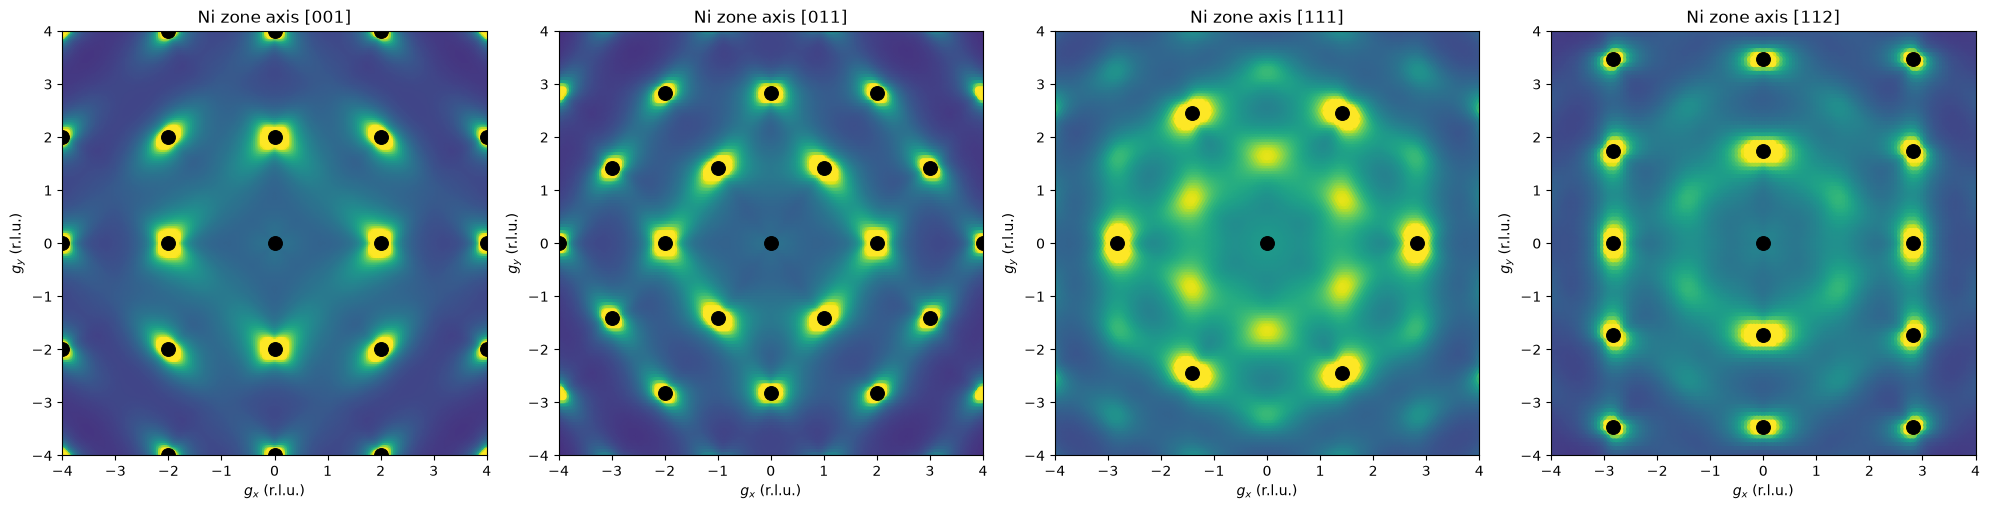

In [15]:
zone_axes = [
    ("[001]", [0, 0, 1], [1, 0, 0]),
    ("[011]", [0, 1, 1], [1, 0, 0]),
    ("[111]", [1, 1, 1], [1, -1, 0]),
    ("[112]", [1, 1, 2], [1, -1, 0]),
]

K_volume = build_K_volume(k_lim=6, K_step=24)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, zone, zone_x) in zip(axes, zone_axes):
    K_zone, K_zone_rotated = K_zone_slice(K_volume, zone, zone_x, thickness=0.001)
    TDS = first_order_tds(K_zone)
    TDS_c = np.clip(TDS, 0, np.percentile(TDS, 99))

    order = TDS_c.argsort()   # plot brightest points last, on top
    ax.scatter(K_zone_rotated[order, 0], K_zone_rotated[order, 1],
               c=np.sqrt(TDS_c[order]), s=20, cmap="viridis")

    zone_n = np.asarray(zone, float)
    zone_n /= np.linalg.norm(zone_n)
    R = rotation_matrix(zone_n, np.asarray(zone_x, float))
    in_plane = np.abs(G_candidates @ zone_n) < 1e-6
    nearby = np.linalg.norm(G_candidates, axis=1) < 4.5
    G_rotated = coord_rotation(G_candidates[in_plane & nearby], R)
    ax.scatter(G_rotated[:, 0], G_rotated[:, 1], s=100, facecolors="black",
               edgecolors="black", linewidths=0.7)

    ax.set_title(f"Ni zone axis {name}")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.set_xlabel("$g_x$ (r.l.u.)")
    ax.set_ylabel("$g_y$ (r.l.u.)")

plt.tight_layout()
plt.show()

## TDS at different temperatures

Since `first_order_tds` takes `Temp`/`B_DW` as parameters (defaulting to the values
set above), the same zone-axis slice can be re-evaluated at any other temperature by
passing `Temp=...` and `B_DW=debye_waller_B(...)` explicitly — both the thermal
population factor and the Debye-Waller attenuation update consistently.

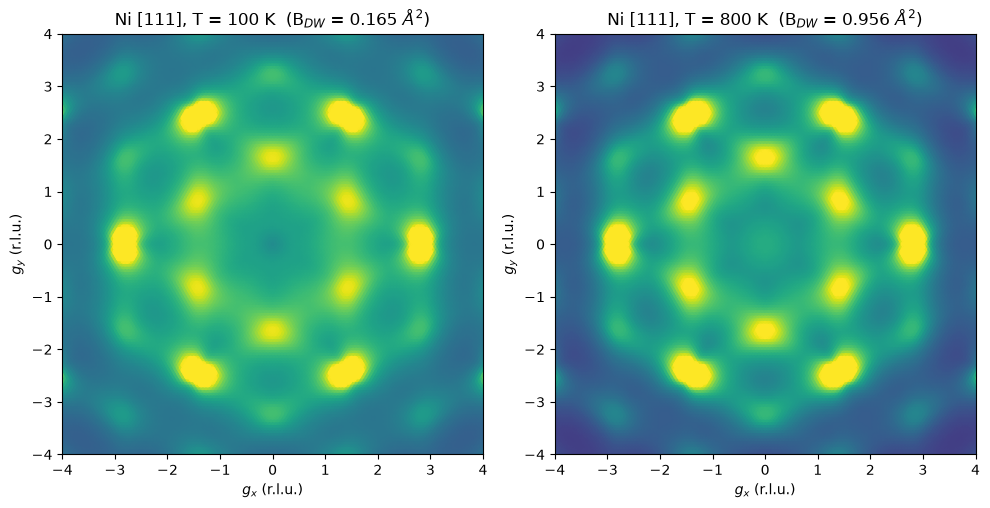

In [13]:
zone, zone_x = [1, 1, 1], [1, -1, 0]
K_zone, K_zone_rotated = K_zone_slice(K_volume, zone, zone_x, thickness=0.001)

compare_temps = [100, 800]   # K

fig, axes = plt.subplots(1, len(compare_temps), figsize=(10, 5))
for ax, T in zip(axes, compare_temps):
    TDS_T = first_order_tds(K_zone, Temp=T, B_DW=debye_waller_B(T))
    TDS_c = np.clip(TDS_T, 0, np.percentile(TDS_T, 99))
    order = TDS_c.argsort()
    ax.scatter(K_zone_rotated[order, 0], K_zone_rotated[order, 1],
               c=np.sqrt(TDS_c[order]), s=20, cmap="viridis")
    ax.set_title(f"Ni [111], T = {T} K  (B$_{{DW}}$ = {debye_waller_B(T):.3f} $\\AA^2$)")
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.set_xlabel("$g_x$ (r.l.u.)")
    ax.set_ylabel("$g_y$ (r.l.u.)")

plt.tight_layout()
plt.show()